In [1]:
import pandas as pd
import sqlite3

# Load the CSV
df = pd.read_csv("vahan_cv_registrations.csv")

# Quick look at the data first
print(df.columns.tolist())
print(df.head())

['_id', 'id', 'date', 'state_name', 'state_code', 'office_name', 'office_code', 'type', 'category', 'registrations']
   _id  id        date                   state_name  state_code  \
0    1   0  01-04-2020  Andaman And Nicobar Islands          35   
1    2   1  01-04-2020  Andaman And Nicobar Islands          35   
2    3   2  01-04-2020  Andaman And Nicobar Islands          35   
3    4   3  01-04-2020  Andaman And Nicobar Islands          35   
4    5   4  01-04-2020  Andaman And Nicobar Islands          35   

      office_name office_code                        type          category  \
0  Port Blair Dto         AN1         Heavy Goods Vehicle  Vehicle Category   
1  Port Blair Dto         AN1         Light Goods Vehicle  Vehicle Category   
2  Port Blair Dto         AN1         Light Motor Vehicle  Vehicle Category   
3  Port Blair Dto         AN1     Light Passenger Vehicle  Vehicle Category   
4  Port Blair Dto         AN1  Other Than Mentioned Above  Vehicle Category   

   re

In [2]:
%matplotlib inline

In [3]:
# loading and inspecting data
import pandas as pd

df = pd.read_csv("vahan_cv_registrations.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

print(df.shape)
print(df["type"].unique())

(584267, 10)
['Heavy Goods Vehicle' 'Light Goods Vehicle' 'Light Motor Vehicle'
 'Light Passenger Vehicle' 'Other Than Mentioned Above' 'Two Wheeler(Nt)'
 'Medium Goods Vehicle' 'Three Wheeler(T)' 'Heavy Passenger Vehicle'
 'Medium Motor Vehicle' 'Medium Passenger Vehicle' 'Three Wheeler(Nt)'
 'Heavy Motor Vehicle' 'Two Wheeler(T)' 'Two Wheeler (Invalid Carriage)'
 'Four Wheeler (Invalid Carriage)']


In [4]:
#filter to cv only
cv_df = df[df["type"].str.contains("Goods", case=False, na=False)].copy()
cv_df = cv_df.dropna(subset=["state_name", "registrations"])
cv_df = cv_df[cv_df["registrations"] > 0]

print(f"CV rows: {cv_df.shape[0]} across {cv_df['state_name'].nunique()} states")

CV rows: 159391 across 37 states


In [8]:
#feature engineering
cv_df["year"] = cv_df["date"].dt.year
cv_df["month"] = cv_df["date"].dt.month_name()

state_yearly = cv_df.groupby(["state_name", "year"])["registrations"].sum().reset_index()
state_yearly["yoy_growth"] = state_yearly.groupby("state_name")["registrations"].pct_change() * 100

In [7]:
# Top 5 states overall
top5 = cv_df.groupby("state_name")["registrations"].sum().sort_values(ascending=False).head(5)
print("TOP 5 STATES:\n", top5)

# Latest year YoY growth, sorted
latest_year = state_yearly["year"].max()
top_growth = state_yearly[state_yearly["year"] == latest_year].sort_values("yoy_growth", ascending=False).head(5)
print("\nTOP GROWTH STATES (latest year):\n", top_growth)

TOP 5 STATES:
 state_name
Andhra Pradesh       5807474
Tamil Nadu           4728400
Rajasthan            3490484
Arunachal Pradesh    3170623
Kerala               2341303
Name: registrations, dtype: int64

TOP GROWTH STATES (latest year):
      state_name  year  registrations  yoy_growth
137    Nagaland  2024           6357  -37.596937
125   Meghalaya  2024           2156  -41.761210
149  Puducherry  2024            242  -43.589744
167      Sikkim  2024            222  -44.500000
101      Ladakh  2024            465  -45.165094


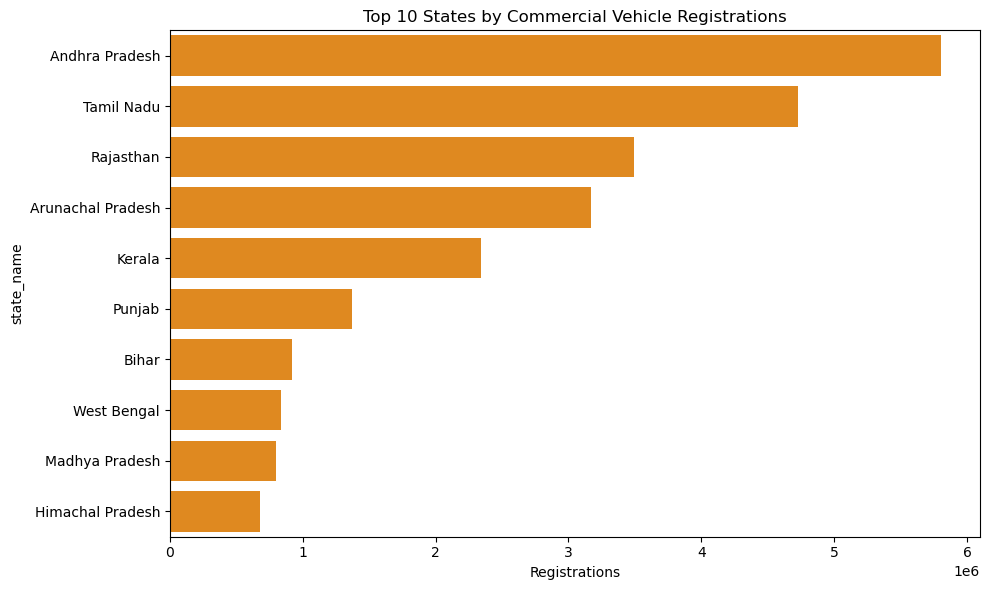

In [9]:
#visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 states chart
top_states = cv_df.groupby("state_name")["registrations"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, color="darkorange")
plt.title("Top 10 States by Commercial Vehicle Registrations")
plt.xlabel("Registrations")
plt.tight_layout()
plt.savefig("top_cv_states.png")
plt.show()

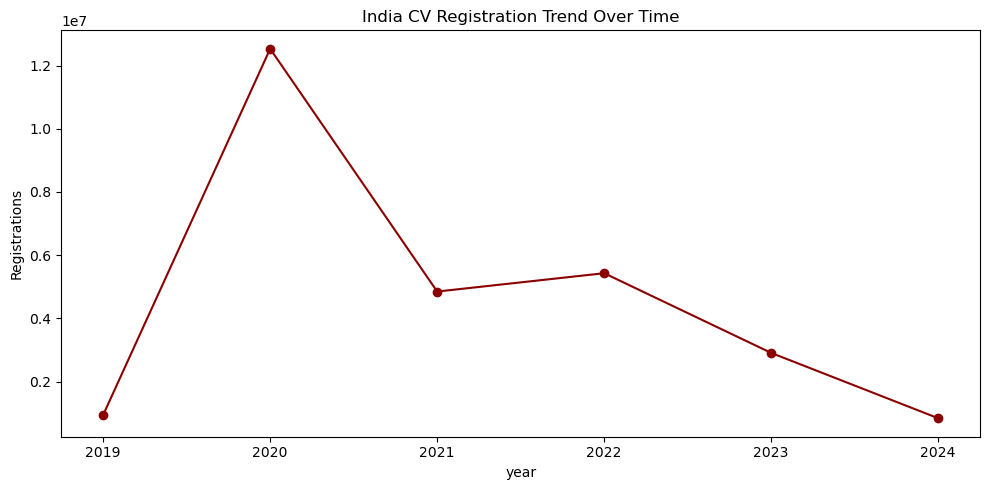

In [10]:
#national trend
national_trend = cv_df.groupby("year")["registrations"].sum()
plt.figure(figsize=(10,5))
national_trend.plot(marker="o", color="darkred")
plt.title("India CV Registration Trend Over Time")
plt.ylabel("Registrations")
plt.tight_layout()
plt.savefig("cv_national_trend.png")
plt.show()

In [11]:
#cleaned data
cv_df.to_csv("cv_registrations_cleaned.csv", index=False)
state_yearly.to_csv("cv_state_yearly_growth.csv", index=False)

In [12]:
print(cv_df["date"].max())
print(cv_df[cv_df["year"] == 2024]["date"].dt.month.unique())

2024-05-01 00:00:00
[4 2 1 3 5]


In [13]:
complete_years = state_yearly[state_yearly["year"] < cv_df["year"].max()]
top_growth = complete_years.sort_values("yoy_growth", ascending=False).head(5)
print(top_growth)

            state_name  year  registrations    yoy_growth
13   Arunachal Pradesh  2020         630320  28140.143369
67    Himachal Pradesh  2020         635485   6347.042711
169         Tamil Nadu  2020        4441726   6264.689699
151             Punjab  2020        1287876   6219.002993
7       Andhra Pradesh  2020        1872411   3992.791099


In [14]:
print(cv_df[cv_df["state_name"] == "Arunachal Pradesh"]["office_name"].value_counts())

office_name
Itanagar Capital Region    182
Lower Siang                168
Lower Dibang Valley        142
West Kameng                135
Namsai                     135
Yupia                      134
Lower Subansiri            127
East Siang                 126
Changlang                  113
Lohit                      112
Tawang                     106
West Siang                  87
Upper Siang                 81
Tirap                       79
Kurung Kumey                58
Longding                    55
Upper Subansiri             44
East Kameng                 39
Siang                       34
Anjaw                       27
Kamle                       24
Leparada                    21
Kra-Daadi                   18
Shi-Yomi                    17
Pakke-Kesang                17
Dibang Valley                5
Name: count, dtype: int64


In [16]:
print(cv_df["date"].min(), cv_df["date"].max())
print(cv_df.groupby("year")["date"].count())

2019-01-01 00:00:00 2024-05-01 00:00:00
year
2019    31048
2020    24901
2021    29338
2022    30280
2023    30686
2024    13138
Name: date, dtype: int64


In [17]:
print(cv_df[cv_df["year"] == 2019]["date"].dt.month.unique())

[ 4  8 12  2  1  7  6  3  5 11 10  9]


In [18]:
print(state_yearly[state_yearly["state_name"] == "Arunachal Pradesh"])

           state_name  year  registrations    yoy_growth
12  Arunachal Pradesh  2019           2232           NaN
13  Arunachal Pradesh  2020         630320  28140.143369
14  Arunachal Pradesh  2021         696157     10.445012
15  Arunachal Pradesh  2022         896194     28.734467
16  Arunachal Pradesh  2023         944531      5.393587
17  Arunachal Pradesh  2024           1189    -99.874117


In [19]:
print(state_yearly[state_yearly["year"] == 2019].sort_values("registrations").head(10))

                   state_name  year  registrations  yoy_growth
0    Andaman & Nicobar Island  2019            158         NaN
96                     Ladakh  2019            246         NaN
162                    Sikkim  2019            372         NaN
144                Puducherry  2019            613         NaN
30                 Chandigarh  2019            879         NaN
48                        Goa  2019           1756         NaN
114                   Manipur  2019           1773         NaN
185          UT of DNH and DD  2019           2076         NaN
12          Arunachal Pradesh  2019           2232         NaN
126                   Mizoram  2019           2424         NaN


In [20]:
reliable_years = [2020, 2021, 2022, 2023]
clean_growth = state_yearly[state_yearly["year"].isin(reliable_years)]

top_growth = clean_growth.sort_values("yoy_growth", ascending=False).head(10)
print(top_growth)

            state_name  year  registrations    yoy_growth
13   Arunachal Pradesh  2020         630320  28140.143369
67    Himachal Pradesh  2020         635485   6347.042711
169         Tamil Nadu  2020        4441726   6264.689699
151             Punjab  2020        1287876   6219.002993
7       Andhra Pradesh  2020        1872411   3992.791099
43               Delhi  2020         576678   2853.536492
91              Kerala  2020         646605   2362.319117
103     Madhya Pradesh  2020         653609   1842.259004
199        West Bengal  2020         664397   1090.419623
128            Mizoram  2021          21466   1082.048458


In [21]:
# Keep only reliable years — recompute from scratch, don't reuse the old state_yearly
reliable = cv_df[cv_df["year"].isin([2021, 2022, 2023])]

clean_yearly = reliable.groupby(["state_name", "year"])["registrations"].sum().reset_index()
clean_yearly = clean_yearly.sort_values(["state_name", "year"])
clean_yearly["yoy_growth"] = clean_yearly.groupby("state_name")["registrations"].pct_change() * 100

# Now only 2022 and 2023 will have growth numbers (2021 has no prior year in this subset)
top_growth = clean_yearly.dropna(subset=["yoy_growth"]).sort_values("yoy_growth", ascending=False).head(10)
print(top_growth)

                                      state_name  year  registrations  \
91                                       Tripura  2022           3938   
49                                        Ladakh  2022            815   
19                                  Chhattisgarh  2022          24584   
1                    Andaman And Nicobar Islands  2022            399   
61                                     Meghalaya  2022           4265   
88  The Dadra And Nagar Haveli And Daman And Diu  2022           4250   
43                                     Karnataka  2022          66227   
67                                      Nagaland  2022          10294   
94                                 Uttar Pradesh  2022          74276   
55                                   Maharashtra  2022         117912   

    yoy_growth  
91   97.988939  
49   79.120879  
19   68.568294  
1    66.945607  
61   57.729290  
88   57.174556  
43   43.323667  
67   40.207028  
94   37.359914  
55   36.589208  


In [22]:
print(clean_yearly[clean_yearly["year"] == 2023].sort_values("yoy_growth", ascending=False).head(5))

      state_name  year  registrations  yoy_growth
20  Chhattisgarh  2023          29787   21.164172
29       Gujarat  2023          76976   19.300095
41     Jharkhand  2023          27709   17.920674
71        Odisha  2023          36134   17.600729
26           Goa  2023           2658   16.937967


In [23]:
import sqlite3

conn = sqlite3.connect("cv_registrations.db")   # creates a real file, not in-memory
cv_df.to_sql("cv_reg", conn, if_exists="replace", index=False)
conn.close()